# `dyna-pi`: Dynamic Program Improvement

<img style="width: 40%" src="logo.svg" align="right">

The **dynamic program improvement system** (`dyna-pi`) is an interactive tool for
analyzing and improving dynamic programming algorithms.  We developed this tool
because Finding a correct program with the optimal asymptotic runtime can be
unintuitive, time-consuming, and error-prone.  `dyna-pi` aims to automate this
laborious process.

**Key features**:

1) **Dyna language**: A high-level, domain-specific language for clear and concise dynamic program specification.
2) **Efficient solvers**: General-purpose solvers to execute Dyna programs, including agenda-based fixpoint iteration and semiring Newton's method.
3) **Static analysis**: Type analysis and worst-case time/space complexity analyses.
4) **Program transformations**: Meaning-preserving Dyna-to-Dyna transformations, which systematizes the repeated insights of numerous authors when speeding up algorithms.
5) **Optimizer**: A search algorithm for identifying a sequence of transformations that reduce the runtime complexity given an initial, correct program.
6) **Visualization and debugging**: Tools to aid in the development of correct programs, including integration with Jupyter.

The `dyna-pi` system is based on [Tim Vieira](http://timvieira.github.io)'s 2023
[PhD dissertation](http://timvieira.github.io/doc/2023-timv-dissertation.pdf)
(see also defense [video](https://youtu.be/SUOvgaxFxP4) and
[slides](https://docs.google.com/presentation/d/10LTArMtqI3nc0xnBkq_m7b7Qk312PL4Vb_26q6fA6QU/edit?usp=sharing)).
It is also part of the broader [Dyna project](https://dyna.org/).


**Notice.**  This code release is in its early stages and might have some rough edges.
We welcome feedback and contributions through pull requests, email, and our [issue tracker](http://github.com/timvieira/dyna-pi/issues).

# Installation

Install the `dyna-pi` package using `pip`:

In [ ]:
#!pip install -qU "git+https://github.com/timvieira/dyna-pi" >/dev/null

We also make use of the following tools for visualization:

In [ ]:
#!sudo apt install -qq graphviz texlive-latex-extra inkscape

# Demo

In [1]:
import dyna

Helpers

In [2]:
from arsenal import timers, iterview, take, colors
import pylab as pl

Notebook styling to match the slides:

In [3]:
%%html 
<style>
@import url('https://fonts.googleapis.com/css2?family=Permanent+Marker&display=swap');
h1, h2, h3 { font-family: 'Permanent Marker', cursive; }
</style>

# CKY

Context-free parsing with the CKY algorithm.

In [4]:
cky = dyna.Program("""

phrase(X,I,K) += rewrite(X,W) * word(W,I,K).                      % base case
phrase(X,I,K) += rewrite(X,Y,Z) * phrase(Y,I,J) * phrase(Z,J,K).  % recursive case
total += phrase(s,0,N) * length(N).

% input declarations
inputs: rewrite(X,Y,Z); rewrite(X,W); word(W,I,K); length(N).
output: total.
""")

In [5]:
cky

{
  0: phrase(X,I,K) += rewrite(X,W) * word(W,I,K).
  1: phrase(X,I,K) += rewrite(X,Y,Z) * phrase(Y,I,J) * phrase(Z,J,K).
  2: total += phrase(s,0,N) * length(N).
}

Below is example input data corresponding to parsing the input sentence `"Papa ate the caviar with the spoon"` with a simple grammar.

In [6]:
cky_grammar = dyna.Program("""

% grammar rules
rewrite(s,np,vp) += 1.
rewrite(np,det,n) += 1.
rewrite(np,np,pp) += 1.
rewrite(vp,v,np) += 1.
rewrite(vp,vp,pp) += 1.
rewrite(pp,p,np) += 1.

rewrite(np,"Papa") += 1.
rewrite(v,"ate") += 1.
rewrite(vp,"ate") += 1.
rewrite(det,"the") += 1.
rewrite(n,"caviar") += 1.
rewrite(p,"with") += 1.
rewrite(n,"spoon") += 1.
""")

cky_sentence = dyna.Program("""
% "Papa ate the caviar with the spoon"
length(7) += 1.
word("Papa",0,1) += 1.
word("ate",1,2) += 1.
word("the",2,3) += 1.
word("caviar",3,4) += 1.
word("with",4,5) += 1.
word("the",5,6) += 1.
word("spoon",6,7) += 1.
""")

cky_data = cky_sentence + cky_grammar

The value of `total` will equal the number of parses of the input sentence.  There are two parses of this sentences becase of the prepositional attachment ambiguity.

In [7]:
cky_sol = cky(cky_data).sol()

In [8]:
cky_sol.user_query('total')

{
  0: total += 2.0.
}

In [ ]:
#cky_sol

## Visualization

We can instantiate the program rules against the solution to see them firing.

In [9]:
dyna.util.display_groundings(cky, cky_sol)

,"phrase(X,I,K) += rewrite(X,W) * word(W,I,K)"
1.0,"phrase(np,0,1) += rewrite(np,""Papa"") * word(""Papa"",0,1)"
1.0,"phrase(v,1,2) += rewrite(v,""ate"") * word(""ate"",1,2)"
1.0,"phrase(vp,1,2) += rewrite(vp,""ate"") * word(""ate"",1,2)"
1.0,"phrase(det,2,3) += rewrite(det,""the"") * word(""the"",2,3)"
1.0,"phrase(det,5,6) += rewrite(det,""the"") * word(""the"",5,6)"
1.0,"phrase(n,3,4) += rewrite(n,""caviar"") * word(""caviar"",3,4)"
1.0,"phrase(p,4,5) += rewrite(p,""with"") * word(""with"",4,5)"
1.0,"phrase(n,6,7) += rewrite(n,""spoon"") * word(""spoon"",6,7)"
,"phrase(X,I,K) += rewrite(X,Y,Z) * phrase(Y,I,J) * phrase(Z,J,K)"
1.0,"phrase(s,0,2) += rewrite(s,np,vp) * phrase(np,0,1) * phrase(vp,1,2)"


We can visualize the computation performed in the program as a computation graph.

In [10]:
#dyna.util.open_html\
((cky + cky_data).instantiate(cky_sol).draw())

Hypergraph(nodes=39)

This kind of computation graph is sometimes called a **packed forest** as represents a forest of derivation trees, which we *unpack* below:

In [11]:
#dyna.util.open_html\
((cky + cky_data).derivations(10, 'total').render_graphviz())

Output()

The computation graph is essentially a collection of derivations packed together such that common derivations are shared.  The computation graph allows us to represent a larger number of derivations compactly.

## Solvers

Let's see how CKY works on the small grammar

In [12]:
p = cky + cky_data   # add the input data to the program rules

**Forward chaining** is an iterative algorithm.  In each iteration, it applies the rules of the program to a **chart** (solution estimate) to derive the next chart.  Once the chart is unchanged, the algorithm halts.

In [13]:
chart = dyna.Program(inputs='')
iterates = [chart]
while True:
    new_chart = p.step(chart)
    iterates.append(new_chart)
    if chart == new_chart: break
    chart = new_chart

In [14]:
def my_update_function(current_index):
    dyna.util.display_chart_and_groundings(cky, iterates[current_index-1], iterates[current_index])
dyna.util.FunctionDisplay(my_update_function, start=1, end=len(iterates)-1);

Output()

We can also visualize how the graph grows incrementally.

In [15]:
def my_update_function(current_index):
    display(p.instantiate(iterates[current_index]).draw())
dyna.util.FunctionDisplay(my_update_function, start=0, end=len(iterates)-1);

Output()

## Solving Cyclical Programs

In [16]:
geom = dyna.Program("""
x += a * x.
x += 1.
a += 0.5.

outputs: x.
""")

In [17]:
geom.draw()

Hypergraph(nodes=2)

In [18]:
dyna.util.interactive_forward_chaining(geom);

Output()

In [19]:
geom.fc(5).user_query('x')

{
  0: x += 1.9375.
}

In [20]:
geom.fc(10).user_query('x')

{
  0: x += 1.998046875.
}

In [21]:
geom.fc(100).user_query('x')

{
  0: x += 2.0.
}

Convergence rate depends on the value of $\texttt{a}$:  

- If $|\texttt{a}|$ is small, numerical convergence is fast

- If $|\texttt{a}| \ge 1$ forward chaining will diverge.

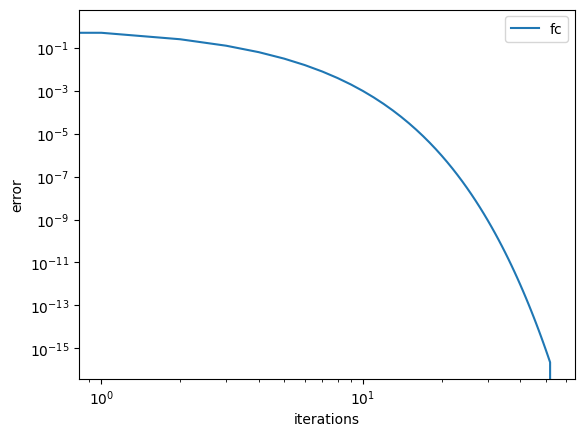

In [22]:
want = 2
err_fc = [abs(want - chart.rules[0].body[0]) for chart in take(100, geom._fc()) if chart]
pl.loglog(err_fc, label='fc'); pl.ylabel('error'); pl.xlabel('iterations'); pl.legend(loc='best');

**A harder cyclical program.** Numerical convergence of forward chaining can be slow.  The following program (due to [Etessami and Yannakakis (2009)](https://dl.acm.org/doi/10.1145/1462153.1462154)) shows a case where fixpoint iteration is *very* slow to converge and Netwon's algorithm is much faster.

In [23]:
slow = dyna.Program("""

x += 0.5 * x * x.
x += 0.5.

outputs: x.

""")

The solution to this program is `x = 1`.  The equation is
$$
\newcommand{\sem}[1]{{\color{magenta}[[
{\color{black}\tt #1} ]] }}
\sem{x} = \frac{1}{2} \sem{x}^2 + \frac{1}{2}
$$

On this program, forward chaining converges *very* slowly.

In [24]:
slow.fc(100)

{
  0: x += 0.9812084402587709.
}

In [25]:
slow.fc(1_000)

{
  0: x += 0.9980172182771205.
}

For difficult cyclical programs, we use a generalized Newton's algorithm to solve for the values.

In [26]:
slow.newton(10)

{
  0: x += 0.9990234375.
}

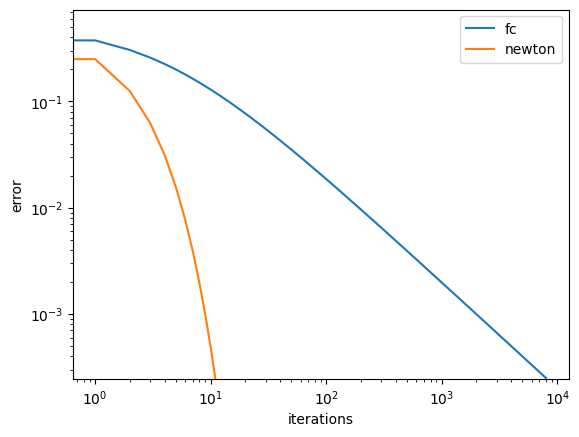

In [27]:
want = 1
err_fc = [abs(want - chart.rules[0].body[0]) for chart in take(8_000, slow._fc()) if chart]
err_newton = [abs(want - chart.rules[0].body[0]) for (_, _, _, _, chart) in take(12, slow._newton())]
pl.loglog(err_fc, label='fc')
pl.loglog(err_newton, label='newton')
pl.ylabel('error'); pl.xlabel('iterations'); pl.ylim(min(min(err_fc), min(err_newton)), None)
pl.legend(loc='best');

Newton's algorithm solves the geometric series in a single iteration!

In [28]:
geom.newton().user_query('x')

{
  0: x += 2.0.
}

The `newton` solver works on more general programs, e.g., CKY.

In [29]:
(cky + cky_data).newton().user_query('total')

{
  0: total += 2.0.
}

# Transformations

## Basic Unfold  and Fold

**Unfold**: Below, we unfold the `q` subgoal of the first rule.  This replaces the subgoal with the bodies of the two rules that define it.  **Fold** does the opposite.

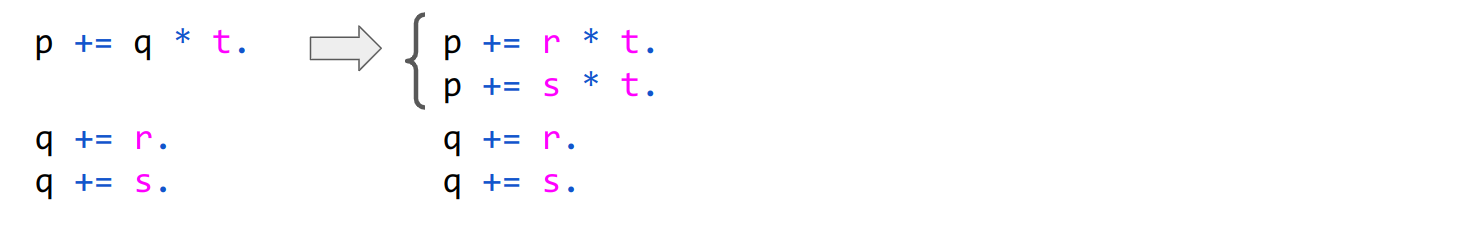

## Explicit Paths

The program below is a rather direct way to write the sum over all paths in a graph that start in a set `start` and end in a set `stop`.

In [30]:
explicit_path = dyna.Program("""

path([X]) += stop(X).
path([X1,X2|Xs]) += edge(X1,X2) * path([X2|Xs]).

goal += start(X) * path([X|Xs]).

inputs: start(_); edge(_,_); stop(_).
outputs: goal.
""")

In [31]:
path_data = dyna.Program("""
start(a) += 1.
edge(a,b) += 0.5.
edge(b,c) += 0.5.
edge(c,a) += 0.5.
stop(a) += 1.
""")

In [32]:
(explicit_path + path_data).fc(20)

{
  0: path([a]) += 1.0.
  1: path([a,b,c,a]) += 0.125.
  2: path([a,b,c,a,b,c,a]) += 0.015625.
  3: path([a,b,c,a,b,c,a,b,c,a]) += 0.001953125.
  4: path([a,b,c,a,b,c,a,b,c,a,b,c,a]) += 0.000244140625.
  5: path([a,b,c,a,b,c,a,b,c,a,b,c,a,b,c,a]) += 3.0517578125e-05.
  6: path([a,b,c,a,b,c,a,b,c,a,b,c,a,b,c,a,b,c,a]) += 3.814697265625e-06.
  7: path([b,c,a]) += 0.25.
  8: path([b,c,a,b,c,a]) += 0.03125.
  9: path([b,c,a,b,c,a,b,c,a]) += 0.00390625.
  10: path([b,c,a,b,c,a,b,c,a,b,c,a]) += 0.00048828125.
  11: path([b,c,a,b,c,a,b,c,a,b,c,a,b,c,a]) += 6.103515625e-05.
  12: path([b,c,a,b,c,a,b,c,a,b,c,a,b,c,a,b,c,a]) += 7.62939453125e-06.
  13: path([c,a]) += 0.5.
  14: path([c,a,b,c,a]) += 0.0625.
  15: path([c,a,b,c,a,b,c,a]) += 0.0078125.
  16: path([c,a,b,c,a,b,c,a,b,c,a]) += 0.0009765625.
  17: path([c,a,b,c,a,b,c,a,b,c,a,b,c,a]) += 0.0001220703125.
  18: path([c,a,b,c,a,b,c,a,b,c,a,b,c,a,b,c,a]) += 1.52587890625e-05.
  19: goal += 1.142852783203125.
  20: start(a) += 1.0.
  21: edge(a,b) += 0.5.
  22: edge(b,c) += 0.5.
  23: edge(c,a) += 0.5.
  24: stop(a) += 1.0.
}

💡 **Idea**:  Let's invent a new item that sums the tail of the list.  Initially, this definition is inefficient, but we will transform it into something much better!

In [33]:
explicit_path_1 = explicit_path.define('pathend(X) += path([X|Xs]).')
explicit_path_1

{
  0: path([X]) += stop(X).
  1: path([X1,X2|Xs]) += edge(X1,X2) * path([X2|Xs]).
  2: goal += start(X) * path([X|Xs]).
  3: pathend(X) += path([X|Xs]).
}

We can graft the new item into the definition for `goal` using fold:

In [35]:
explicit_path_2 = explicit_path_1.megafolds()[0]
explicit_path_2

{
  0: goal += pathend(X) * start(X).
  1: path([X]) += stop(X).
  2: path([X1,X2|Xs]) += edge(X1,X2) * path([X2|Xs]).
  3: pathend(X) += path([X|Xs]).
}

Now, we can transform the definition of `pathend` so that it recursively calls itself rather than calling the inefficient `path` items.

Unfold

In [36]:
explicit_path_3 = explicit_path_2.unfold(3,0)
explicit_path_3

{
  0: goal += pathend(X) * start(X).
  1: path([X]) += stop(X).
  2: path([X1,X2|Xs]) += edge(X1,X2) * path([X2|Xs]).
  3: pathend(X) += stop(X).
  4: pathend(X) += edge(X,X2) * path([X2|Xs]).
}

Fold

In [37]:
explicit_path_4 = explicit_path_3.megafolds(explicit_path_1)[2].sort()
explicit_path_4

{
  0: goal += pathend(X) * start(X).
  1: path([X]) += stop(X).
  2: path([X1,X2|Xs]) += edge(X1,X2) * path([X2|Xs]).
  3: pathend(X) += pathend(X2) * edge(X,X2).
  4: pathend(X) += stop(X).
}

Remove the `path` items as they are now defunct! ⚡

In [38]:
explicit_path_5 = explicit_path_4.prune().sort()
explicit_path_5

{
  0: goal += pathend(X) * start(X).
  1: pathend(X) += pathend(X2) * edge(X,X2).
  2: pathend(X) += stop(X).
}

We can run the optimized program.  We observe that the number of items is now bounded!

In [39]:
explicit_path_5(path_data).sol()

{
  0: start(a) += 1.0.
  1: edge(a,b) += 0.5.
  2: edge(b,c) += 0.5.
  3: edge(c,a) += 0.5.
  4: stop(a) += 1.0.
  5: pathend(a) += 1.1428571343421936.
  6: goal += 1.1428571343421936.
  7: pathend(c) += 0.5714285671710968.
  8: pathend(b) += 0.2857142835855484.
}

We can analyze the program

In [40]:
path_input_type = """
start(I) += n(I).
edge(I,K) += n(I) * n(K).
stop(K) += n(K).
inputs: n(N).
"""

In [41]:
explicit_path_5.type_analysis(path_input_type).runtime().x.expand()

n**2 + 4*n + 6

We can automate the search for the transformation sequence:

In [42]:
opt = explicit_path.optimizer().run(500)
best = opt.optimize_plans().prune()
best

{
  0: goal += $gen1(X) * start(X).
  1: $gen1(X) += $gen1(X2) * edge(X,X2).
  2: $gen1(X) += stop(X).
}

The runtime analyzer returns a quadractic time bound.  Note that this bound assumes an acyclic graph, or that the semiring is k-closed (e.g., min-plus).

In [43]:
runtime = best.type_analysis(path_input_type).runtime().x.expand()
runtime

n**2 + 4*n + 6

The original program was unbounded so our runtime bound says it will take infinite time.

In [44]:
explicit_path.type_analysis(path_input_type).runtime().x.expand()

oo

# Additional Material

## Simple Fold-Unfold

In [ ]:
pqrst = dyna.Program("""
p += q * `t`.
q += `r`.
q += `s`.
""", semiring=dyna.Symbol)

In [ ]:
pqrst.unfold(0,0).sort()

**Fold** is the mirror image of unfold.

In [ ]:
dyna.Program("""
p += `r` * `t`.
p += `s` * `t`.
q += `r`.
q += `s`.
""").megafolds()[0]

**Strongly equivalent:** a value-preserving bijections between the derivation sets

In [ ]:
pqrst.derivations(10,'X')

In [ ]:
table = []
for x in pqrst.derivations(10,'X'):
    y = pqrst.Transform(x, pqrst.unfold(0,0))   # apply the bijective mapping
    table.append([x, y])

In [ ]:
dyna.util.display_table(table)

## All-Pairs to Single-Source Paths

In [ ]:
paths = dyna.Program("""

goal += start(I) * path(I,K) * stop(K).

path(I,K) += path(I,J) * edge(J,K).
path(I,I).

inputs: start(_); edge(_,_); stop(_).
outputs: goal.

""")

In [ ]:
paths1 = paths.define('startpath(K) += start(I) * path(I,K).')
paths1

In [ ]:
paths2 = paths1.megafolds(paths1)[0]
paths2

In [ ]:
paths3 = paths2.unfold(3,1)
paths3

In [ ]:
paths4 = paths3.megafolds(paths1)[1]
paths4.sort().prune()

## Length-4 Paths in a Graph

In [ ]:
path4 = dyna.Program("""
total += w(Y₁,Y₂) * w(Y₂,Y₃) * w(Y₃,Y₄) * w(Y₄,Y₅).

inputs: w(_,_).
output: total.
""")

In [ ]:
path4_input_type = """
w(I,J) += n(I) * n(J). 
inputs: n(_).
"""

In [ ]:
path4_opt = path4.beam(50,5,verbosity=0).best.sort()
display(path4_opt)
display(path4_opt.type_analysis(path4_input_type).runtime().x.expand())

## CKY - Speedup

In [ ]:
cky

In [ ]:
cky_optimized = cky.define('tmp(X,I,J,Z) += rewrite(X,Y,Z) * phrase(Y,I,J).').megafolds()[0]

In [ ]:
cky_optimized

In [ ]:
cky_input_type = """

params:
    k(X);   % grammar symbols
    w(W);   % sentence symbols
    n(I).   % sentence positions

word(W,I,K) += w(W) * n(I) * n(K).
length(N) += n(N).
rewrite(X,Y,Z) += k(X) * k(Y) * k(Z).
rewrite(X,W) += k(X) * w(W).

"""
cky_optimized.type_analysis(cky_input_type).runtime(fast_mode=1).x.expand()

In [ ]:
cky.type_analysis(cky_input_type).runtime(fast_mode=1).x.expand()

Since the number of nonterminals over each span is small in this program the savings due to the "hook trick" are small.

In [ ]:
D = cky_data

T = timers()
for _ in iterview(range(25)):
    with T['cky-optimized']:
        cky_optimized(D)    
    with T['cky-basic']:
        cky(D)
T.compare()

In [ ]:
synthetic_data = dyna.Program("""
word(W,I,K) += w(W) * n(I) * n(K) * (K is I + 1).
length(N) += n(N).
rewrite(X,Y,Z) += k(X) * k(Y) * k(Z).
rewrite(X,W) += k(X) * w(W).

w("a").
k(a). k(b). k(c). k(d). k(e). k(f). k(s).
n(0). n(1). n(2). n(3). n(4). n(5). n(6).
""").sol()
#cky(synthetic_data).user_query('total')

D = synthetic_data

T = timers()
for _ in iterview(range(5)):
    with T['cky-optimized']:
        cky_optimized(D)    
    with T['cky-basic']:
        cky(D)
T.compare()

## CKY - Unfold Grammar

We can use unfold to specialize the program to the specific grammar

In [ ]:
cky + cky_grammar

In [ ]:
cky_specialized = (cky + cky_grammar).set_input_types('word(_,_,_). length(_).').unfold(1,0).unfold(0,0).constant_folding().prune()
cky_specialized

In [ ]:
T = timers()
for _ in iterview(range(25)):
    with T['cky-specialized']:
        cky_specialized(cky_sentence)
    with T['cky-basic']:
        cky(cky_data)
T.compare()

## Unfolding the Geometric Series

In [ ]:
geom = dyna.Program("""
x += `b`.
x += `a` * x.

output: x.
""", semiring=dyna.Symbol)

In [ ]:
geom

Unfolding *once* does what we expect:

In [ ]:
geom.unfold(1,1)

However, unfolding *twice* does something a little weird:

In [ ]:
geom.unfold(1,1).unfold(2,2)

The recurrence has be unrolled to four levels rather than 3.

With **generalized unfold**, we can specify which program to use as **auxiliary definitions**:

In [ ]:
geom.unfold(1,1).unfold(2,2,defs=geom)

And, similarly, **generalized fold** will fold with respect to auxiliary definitions.

## CKY - Program Analysis

Simple input-type specification:

In [ ]:
cky_input_type = """

params:
    k(X);   % grammar symbols
    w(W);   % sentence symbols
    n(I).   % sentence positions

word(W,I,K) += w(W) * n(I) * n(K) * (I < K).
length(N) += n(N).
rewrite(X,Y,Z) += k(X) * k(Y) * k(Z).
rewrite(X,W) += k(X) * w(W).

"""
cky_t = cky.type_analysis(cky_input_type, """
(I < K) :- (I < J), (J < K).
$fail :- (I < I).
""")
cky_t

Space complexity

In [ ]:
cky_t.size().x

Runtime complexity

In [ ]:
cky_t.runtime(fast_mode=1).x.expand()

## Semirings

**Boolean**

In [ ]:
(cky + cky_data).lift_semiring(dyna.Boolean).user_query('total')

**Min-plus** will give us the smallest derivation where size is measured as the number of nodes.

In [ ]:
(cky + cky_data).lift_semiring(dyna.MinPlus).user_query('total')

**Top K** will give us an iterator over derivations ordered from highest-to-lowest weight.  Since these lists tend to be large, we suppress printing them out.

In [ ]:
topk = (cky + cky_data).lift_semiring(dyna.LazySort).user_query('total')
topk

To access the value in Python, we use the rule id (`0`) and position of its subgoal (`0`) to access the semiring value.

In [ ]:
for x in topk.rules[0].body[0]:
    print()
    print(x.score, x.flat_data_list())

**Regular expressions** give a compact representation of the yields.  In the case of CKY, there is only one yield possible.

In [ ]:
class NewSymbol(dyna.Symbol):
    @classmethod
    def lift(cls, x, y):
        return dyna.Symbol(y.args[0]) if y.fn == 'word' else dyna.Symbol.one

In [ ]:
(cky + cky_data).lift_semiring(NewSymbol).user_query('total')

The example below that the value of `x` is equal to a regular language ${\tt\color{magenta}a}^* {\tt\color{magenta}b}$ accepted by a finite-state automaton.

In [ ]:
geom = dyna.Program("""
x += `b`.
x += `a` * x.
""", semiring=dyna.Symbol)
geom_sol = geom.newton()
geom_sol

In [ ]:
geom_sol.rules[0].body[0].fsa.min()

## Semi-Automated Search

The `dyna-pi` toolkit supports semi-automated search.

In [ ]:
p = dyna.Program("""

path([X1,X2|Xs]) += edge(X1,X2) * path([X2|Xs]).
path([X]) += stop(X).
goal += start(X) * path([X|Xs]).

inputs: start(_); edge(_,_); stop(_).
outputs: goal.
""")

In the example below, we string together a sequences of search operations that resemble the "tactics" used in proof assistants (e.g., [lean](https://lean-lang.org/)).

In [ ]:
m = dyna.make_smt_measure(p)   # measure-based safety conditions for fold/unfold transformations

C = (p.to_collection()
 .eurekas()
 .unfolds_first()
 .dedup()
 .folds_seq()
 .filter(m.safe)
 .prune_fast()
 .dedup()
)

print(f'{len(C)} nodes')
C.sort(dyna.Program.degrees)[0]

In [ ]:
C.graph

In [ ]:
#from IPython.display import FileLink, FileLinks
#filename = '/tmp/tmp.html'
#with open(filename, 'w', encoding='utf-8') as f: f.write(C.graph._repr_html_())
#FileLink(filename)

The fully automated search explores much more of the graph ($\approx 200$ programs).

In [ ]:
optimizer = p.optimizer(p_greedy=0.5, seed=0)
optimizer.run(200).optimize_plans().prune()

## Type-based Program Specialization

In [ ]:
q = dyna.Program("""
goal += a(I,I).
a(I,K) += b(I,J) * c(J,K).
goal += dead(X).

input: b(_,_); c(_,_).
output: goal.
""")

In [ ]:
q.type_analysis()

In [ ]:
q.usefulness_analysis()

In [ ]:
q.abbreviate(types=q.usefulness_analysis()).prune().sort()

Bounds

In [ ]:
import dyna.analyze.runtime
#n = dyna.analyze.runtime._syms['n']   # symbol name to make it orange
#n.name = colors.orange % 'n'

In [ ]:
q.type_analysis("""
b(I,J) :- n(I), n(J).
c(I,J) :- n(I), n(J).
inputs: n(_).
""").show_runtime()

In [ ]:
q.prune(specialize=True).type_analysis("""
b(I,J) :- n(I), n(J).
c(I,J) :- n(I), n(J).
inputs: n(_).
""").show_runtime()

In [ ]:
S = q.type_analysis("""
b(I,J) :- n(I), n(J).
c(I,J) :- n(I), n(J).
inputs: n(_).
""")

In [ ]:
S.show_size(full=True)

print(colors.light.magenta % '\noverall', S.size())

## Weighted Peano Numbers

This example shows how the left-corner transformation can be used to speed-up the following sum over weighted peano numbers.

In [ ]:
peano = dyna.Program("""
peano(z) += 1.
peano(s(N)) += a * peano(N).
a += 0.5.
goal += peano(N).

outputs: goal.

""")

In [ ]:
sol = peano.fc(30)
sol

In [ ]:
sol.user_lookup('goal')    # approximation to goal is pretty accurate if |a| is small, if |a| >= 1 it diverges.

The following mysterious transformation makes the computation of `goal` program run efficiently:

In [ ]:
peano

In [ ]:
peano_fast = peano.lct({3:0, 1:1}).elim(0).elim(0).prune_fast()
peano_fast

Now, the program runs efficiently as the new items `(goal / peano($X0)` have `$X0` uninstantiated.

In [ ]:
peano_fast.prune(specialize=0).sol()

## Newton's Method ❤️❤️❤️

`dyna-pi` implements an advanced solver based on Newton's method for solving systems of equations, suitably generalized beyond real numbers to operate over semirings!  The papers below are excellent examples of why Newton's is awesome for solving the kinds of cyclical systems of equations that we encounter in probabilistic inference problems and other domains.  Our implementation assumes that the semiring is commutative.

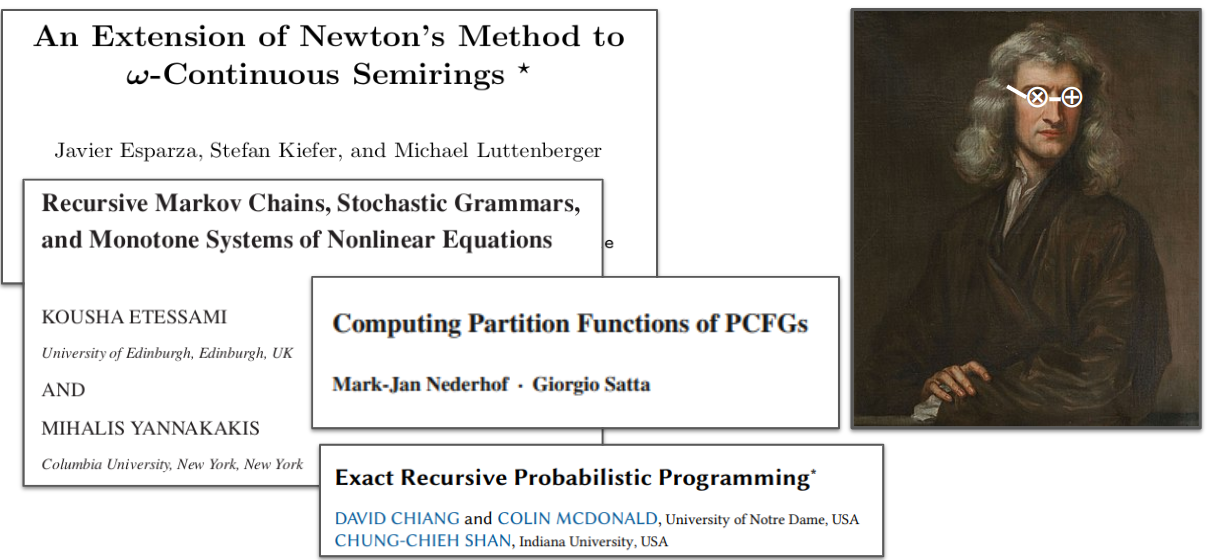

* [An Extension of Newton’s Method to ω-Continuous Semirings](https://link.springer.com/chapter/10.1007/978-3-540-73208-2_17). Javier Esparza, Stefan Kiefer, Michael Luttenberger 

* [Recursive Markov chains, stochastic grammars, and monotone systems of nonlinear equations](https://dl.acm.org/doi/10.1145/1462153.1462154). Kousha Etessami, Mihalis Yannakakis

* [Computing partition functions of PCFGs](https://mjn.host.cs.st-andrews.ac.uk/publications/2008d.pdf). Mark-Jan Nederhof, Giorgio Satta
 
* [Exact Recursive Probabilistic Programming](https://arxiv.org/abs/2210.01206). David Chiang, Colin McDonald, Chung-chieh Shan

* Details and discussion of the Dyna Newton solver are in chapter 5 of [Tim Vieira's dissertation](https://timvieira.github.io/doc/2023-timv-dissertation.pdf)